In [ ]:
# Sub-block 1: Initialization & Card Tracking

# Standard deck, used as default in play_game if no starting_deck is provided
STANDARD_DECK = {
    1: 4,   # Ace
    2: 4,
    3: 4,
    4: 4,
    5: 4,
    6: 4,
    7: 4,
    8: 4,
    9: 4,
    10: 16  # 10, Jack, Queen, King
}

# Sub-block 2: Probability Updates

def get_probabilities(deck, total_cards):
    """
    Returns a dictionary of probabilities for drawing each card value
    based on the current state of the deck.
    """
    if total_cards == 0:
        return {card: 0 for card in deck}
    return {card: count / total_cards for card, count in deck.items()}

def deal_card(card_value, deck, total_cards):
    """
    Removes a card from the deck and returns the updated deck and total.
    """
    deck[card_value] -= 1
    total_cards -= 1
    return deck, total_cards


# Sub-block 3: Dealer Hole Card Probabilities

def get_hole_card_probabilities(deck, total_cards):
    """
    After the 3 known cards are dealt, computes the probability
    that the dealer's hole card is each of the 13 possible values
    based on the remaining deck.
    """
    return get_probabilities(deck, total_cards)

In [ ]:
import random

# Sub-block 4: The Deal Sequence

def draw_random_card(deck, total_cards):
    cards = list(deck.keys())
    weights = [deck[c] for c in cards]
    card = random.choices(cards, weights=weights, k=1)[0]
    return card

def calculate_total(hand):
    total = sum(hand)
    soft = False
    if 1 in hand and total + 10 <= 21:
        total += 10
        soft = True
    return total, soft


def deal_sequence(deck, total_cards, n_players=1):
    players = []
    for i in range(n_players):
        name = f"player{i+1}"
        players.append({
            "name": name,
            "bet": 0,
            "hand": [],
            "total": 0,
            "soft": False
        })

    dealer = {
        "hand": [],
        "total": 0,
        "soft": False
    }

    # Deal 2 cards to each player in order
    for _ in range(2):
        for player in players:
            card = draw_random_card(deck, total_cards)
            deck, total_cards = deal_card(card, deck, total_cards)
            player["hand"].append(card)
            player["total"], player["soft"] = calculate_total(player["hand"])

    # Dealer face up card
    dealer_card_up = draw_random_card(deck, total_cards)
    deck, total_cards = deal_card(dealer_card_up, deck, total_cards)
    dealer["hand"].append(dealer_card_up)
    dealer["total"], dealer["soft"] = calculate_total(dealer["hand"])

    # Capture hole card probabilities from remaining cards
    hole_card_probs = get_hole_card_probabilities(deck, total_cards)
    deck_49, total_49 = deck.copy(), total_cards

    # Draw hole card
    dealer_hole = draw_random_card(deck, total_cards)
    deck, total_cards = deal_card(dealer_hole, deck, total_cards)
    dealer["hand"].append(dealer_hole)

    return players, dealer, hole_card_probs, deck_49, total_49, deck, total_cards

In [ ]:
import numpy as np

# Sub-block 5: Transition Matrices & Final T Matrix

def build_transition_matrix(deck, total_cards):
    if total_cards == 0:
        return np.zeros((20, 20))
    states = list(range(2, 22))
    n = len(states)
    T = np.zeros((n, n))
    probs = get_probabilities(deck, total_cards)
    for j_idx, j in enumerate(states):
        for card, prob in probs.items():
            new_total = j + card
            if card == 1 and j + 11 <= 21:
                new_total = j + 11
            if new_total <= 21:
                i_idx = new_total - 2
                T[i_idx][j_idx] += prob

    # State 21 is absorbing
    T[19][19] = 1.0
    return T


def build_final_transition_matrix(deck_49, total_49, hole_card_probs):
    """
    For each possible hole card, builds a transition matrix from the 48 card
    deck with that card removed, weights it by its probability from the 49
    card snapshot, and sums into the final aggregate transition matrix.
    """
    n = 20
    T_final = np.zeros((n, n))

    for card, prob in hole_card_probs.items():
        if deck_49[card] == 0:
            continue
        deck_copy = deck_49.copy()
        deck_copy[card] -= 1
        total_copy = total_49 - 1
        T_card = build_transition_matrix(deck_copy, total_copy)
        T_final += prob * T_card

    return T_final

In [ ]:
# Sub-block 6: Runs the whole setup

def run_setup(deck, total_cards, n_players=1):
    """
    Runs a full round setup and returns all relevant information.
    """
    players, dealer, hole_card_probs, deck_49, total_49, deck, total_cards = deal_sequence(deck, total_cards, n_players)
    T = build_final_transition_matrix(deck_49, total_49, hole_card_probs)

    return players, dealer, T, deck, total_cards

In [ ]:
# Sub-block 7: Player & Dealer Actions

BANKROLL = 100

BETS = {
    "conservative": 20,
    "normal": 20,
    "risky": 20
}

HIT_THRESHOLDS = {
    "conservative": 14,
    "normal": 16,
    "risky": 17
}

def get_smart_bet(T, current_total, bankroll):
    """
    Smart player bets dynamically based on bust probability from T matrix.
    """
    j_idx = current_total - 2
    bust_chance = 1 - T[:, j_idx].sum()
    bet = int((1 - bust_chance) * 30)
    bet = max(10, min(bet, bankroll))
    return 20

def player_action(player, T, player_type):
    """
    Determines whether the player hits or stands based on their type.
    """
    total = player["total"]
    if player_type == "smart":
        if total == 21:
            return "stand"
        j_idx = total - 2
        bust_chance = 1 - T[:, j_idx].sum()
        action = "stand" if bust_chance >= 0.62 else "hit"
        return action
    else:
        threshold = HIT_THRESHOLDS[player_type]
        return "stand" if total > threshold else "hit"

def play_player_turn(player, deck, total_cards, T, player_type):
    """
    Plays out the player's turn, hitting until they stand or bust.
    """
    while True:
        action = player_action(player, T, player_type)
        if action == "stand":
            break

        if total_cards == 0:
            break

        card = draw_random_card(deck, total_cards)
        deck, total_cards = deal_card(card, deck, total_cards)
        player["hand"].append(card)
        player["total"], player["soft"] = calculate_total(player["hand"])

        # rebuild T after each card drawn
        T = build_transition_matrix(deck, total_cards)

        if player["total"] > 21:
            if player["soft"]:
                player["total"] -= 10
                player["soft"] = False
            else:
                player["status"] = "bust"
                break

    return player, deck, total_cards, T

def play_dealer_turn(dealer, deck, total_cards):
    """
    Dealer hits on 16 and below, stands on soft 17 and above.
    """
    while True:
        dealer["total"], dealer["soft"] = calculate_total(dealer["hand"])

        if dealer["total"] < 17:
            if total_cards == 0:
                break  # forced stand
            card = draw_random_card(deck, total_cards)
            deck, total_cards = deal_card(card, deck, total_cards)
            dealer["hand"].append(card)
        elif dealer["total"] > 21:
            if dealer["soft"]:
                dealer["total"] -= 10
                dealer["soft"] = False
            else:
                dealer["status"] = "bust"
                break
        else:
            break

    return dealer, deck, total_cards

def determine_winner(player, dealer):
    """
    Determines the outcome of the round.
    Returns 'player', 'dealer', or 'push'.
    """
    if player.get("status") == "bust":
        return "dealer"
    if dealer.get("status") == "bust":
        return "player"
    if player["total"] > dealer["total"]:
        return "player"
    if dealer["total"] > player["total"]:
        return "dealer"
    return "push"

In [ ]:
# Sub-block 8: Play Game

def play_game(player_types=None, n_players=1, starting_deck=None, verbose=True):
    if starting_deck is None:
        deck = STANDARD_DECK.copy()
    else:
        deck = starting_deck.copy()
    if player_types is None:
        player_types = [PLAYER_TYPE] * n_players

    total_cards = sum(deck.values())
    min_cards = (n_players * 2) + 2

    player_stats = []
    for i in range(n_players):
        player_stats.append({
            "name": f"player{i+1}",
            "type": player_types[i],
            "bankroll": BANKROLL,
            "bankroll_history": [BANKROLL],  # track bankroll after each round
            "winrate_history": [],           # track cumulative win rate after each round
            "wins": 0,
            "losses": 0,
            "pushes": 0,
            "busts": 0,
            "naturals": 0,
            "totals": []
        })

    game_metrics = {
        "rounds_played": 0,
        "dealer_totals": []
    }

    while total_cards >= min_cards and all(ps["bankroll"] > 0 for ps in player_stats):
        players, dealer, T, deck, total_cards = run_setup(deck, total_cards, n_players)
        dealer["status"] = "active"

        for i, player in enumerate(players):
            player["status"] = "active"
            stats = player_stats[i]
            ptype = stats["type"]  # use each player's own type

            if ptype == "smart":
                bet = get_smart_bet(T, player["total"], stats["bankroll"])
            else:
                bet = BETS[ptype]
            player["bet"] = bet

            if player["total"] == 21:
                stats["naturals"] += 1

            player, deck, total_cards, T = play_player_turn(player, deck, total_cards, T, ptype)

            stats["totals"].append(player["total"])
            if player.get("status") == "bust":
                stats["busts"] += 1

        dealer, deck, total_cards = play_dealer_turn(dealer, deck, total_cards)
        game_metrics["dealer_totals"].append(dealer["total"])

        for i, player in enumerate(players):
            stats = player_stats[i]
            bet = player["bet"]
            result = determine_winner(player, dealer)

            if result == "player":
                stats["wins"] += 1
                stats["bankroll"] += bet
            elif result == "dealer":
                stats["losses"] += 1
                stats["bankroll"] -= bet
            else:
                stats["pushes"] += 1

            # add these three lines here
            stats["bankroll_history"].append(stats["bankroll"])
            total_rounds = game_metrics["rounds_played"] + 1  # +1 because rounds_played hasn't incremented yet
            stats["winrate_history"].append(stats["wins"] / total_rounds)

        game_metrics["rounds_played"] += 1

    game_metrics["player_stats"] = player_stats

    if verbose:
        print(f"Rounds played: {game_metrics['rounds_played']}")
        for stats in player_stats:
              print(f"\n{stats['name']} ({stats['type']}):")
              print(f"  Wins: {stats['wins']}")
              print(f"  Losses: {stats['losses']}")
              print(f"  Pushes: {stats['pushes']}")
              print(f"  Busts: {stats['busts']}")
              print(f"  Naturals: {stats['naturals']}")
              print(f"  Final bankroll: ${stats['bankroll']}")

        game_metrics["player_stats"] = player_stats

    return game_metrics

In [ ]:
# Run the game

%%time

half_deck = {k: v // 2 for k, v in STANDARD_DECK.items()}
deck_6x = {k: v * 6 for k, v in STANDARD_DECK.items()}
deck_10x = {k: v * 10 for k, v in STANDARD_DECK.items()}

# player types: "conservative", "normal", "risky", or "smart"
results = play_game(player_types=["smart"], n_players=1, starting_deck=deck_6x)


Rounds played: 7

player1 (smart):
  Wins: 1
  Losses: 6
  Pushes: 0
  Busts: 2
  Naturals: 0
  Final bankroll: $0
CPU times: user 12 ms, sys: 1 ms, total: 13 ms
Wall time: 13 ms


In [ ]:
# simulation for multiple iterations

from tqdm import tqdm

def run_simulations(n_sims, player_type, n_players=1, starting_deck=None, verbose=False):
    """
    Runs n_sims independent games for a single player type
    and collects metrics across all simulations.
    """
    all_results = []
    for _ in tqdm(range(n_sims), desc=f"Running {player_type} simulations"):
        result = play_game(player_types=[player_type], n_players=n_players, starting_deck=starting_deck, verbose=verbose)
        all_results.append(result)
    return all_results


In [ ]:
n_sims = 1000


smart_results = run_simulations(n_sims, "smart", starting_deck=deck_6x, verbose=False)
normal_results = run_simulations(n_sims, "normal", starting_deck=deck_6x, verbose=False)
conservative_results = run_simulations(n_sims, "conservative", starting_deck=deck_6x, verbose=False)
risky_results = run_simulations(n_sims, "risky", starting_deck=deck_6x, verbose=False)


Running risky simulations: 100%|██████████| 1000/1000 [00:46<00:00, 21.64it/s]


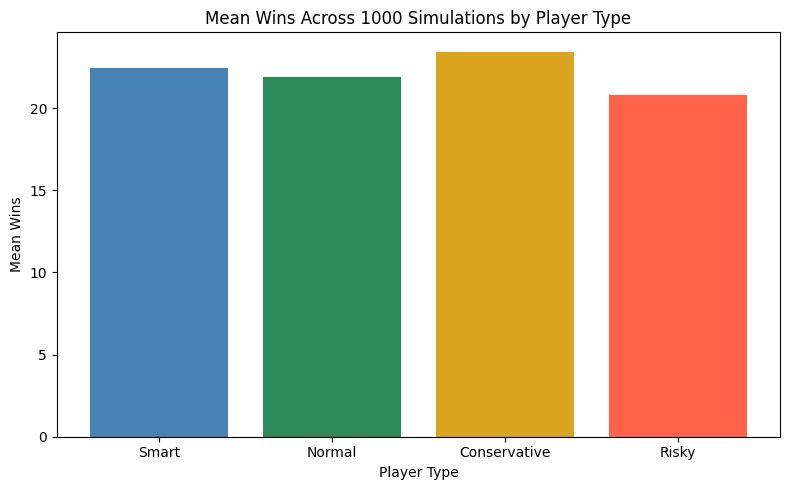

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract wins for each player type
def extract_metric(results, metric):
    return [r["player_stats"][0][metric] for r in results]

smart_wins = extract_metric(smart_results, "wins")
normal_wins = extract_metric(normal_results, "wins")
conservative_wins = extract_metric(conservative_results, "wins")
risky_wins = extract_metric(risky_results, "wins")

# Mean wins per player type
player_types = ["Smart", "Normal", "Conservative", "Risky"]
mean_wins = [np.mean(smart_wins), np.mean(normal_wins), np.mean(conservative_wins), np.mean(risky_wins)]

# Bar plot
plt.figure(figsize=(8, 5))
plt.bar(player_types, mean_wins, color=["steelblue", "seagreen", "goldenrod", "tomato"])
plt.title("Mean Wins Across 1000 Simulations by Player Type")
plt.xlabel("Player Type")
plt.ylabel("Mean Wins")
plt.tight_layout()
plt.show()

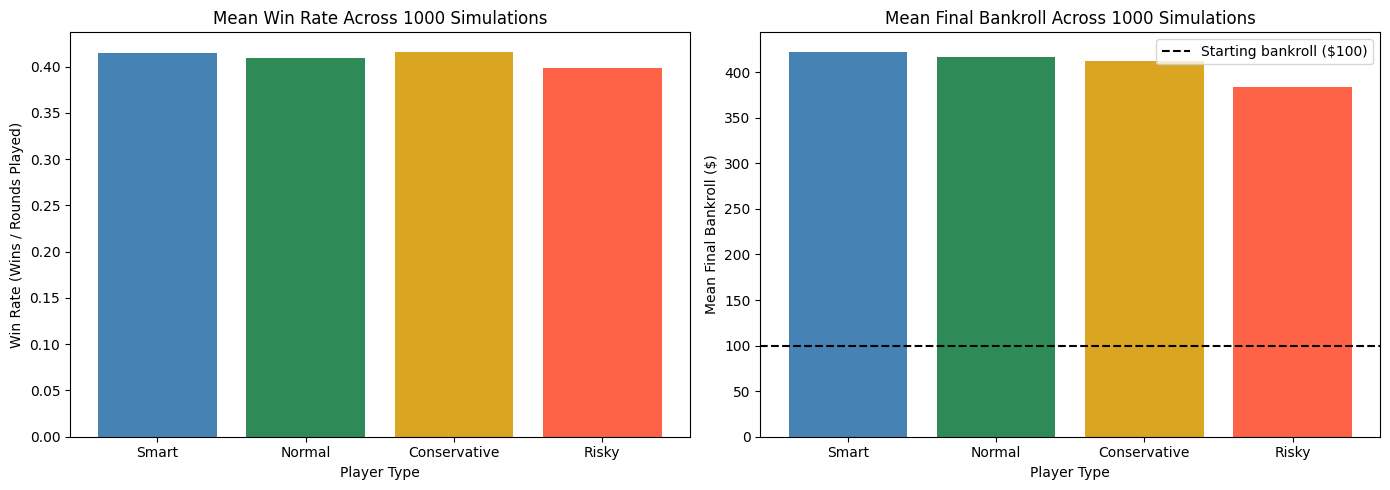

In [ ]:
# Win rate (wins / rounds played)
smart_winrate = [r["player_stats"][0]["wins"] / r["rounds_played"] for r in smart_results]
normal_winrate = [r["player_stats"][0]["wins"] / r["rounds_played"] for r in normal_results]
conservative_winrate = [r["player_stats"][0]["wins"] / r["rounds_played"] for r in conservative_results]
risky_winrate = [r["player_stats"][0]["wins"] / r["rounds_played"] for r in risky_results]

# Final bankroll
smart_bankroll = extract_metric(smart_results, "bankroll")
normal_bankroll = extract_metric(normal_results, "bankroll")
conservative_bankroll = extract_metric(conservative_results, "bankroll")
risky_bankroll = extract_metric(risky_results, "bankroll")

player_types = ["Smart", "Normal", "Conservative", "Risky"]
colors = ["steelblue", "seagreen", "goldenrod", "tomato"]

mean_winrates = [np.mean(smart_winrate), np.mean(normal_winrate), np.mean(conservative_winrate), np.mean(risky_winrate)]
mean_bankrolls = [np.mean(smart_bankroll), np.mean(normal_bankroll), np.mean(conservative_bankroll), np.mean(risky_bankroll)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Win rate plot
axes[0].bar(player_types, mean_winrates, color=colors)
axes[0].set_title("Mean Win Rate Across 1000 Simulations")
axes[0].set_xlabel("Player Type")
axes[0].set_ylabel("Win Rate (Wins / Rounds Played)")

# Final bankroll plot
axes[1].bar(player_types, mean_bankrolls, color=colors)
axes[1].set_title("Mean Final Bankroll Across 1000 Simulations")
axes[1].set_xlabel("Player Type")
axes[1].set_ylabel("Mean Final Bankroll ($)")
axes[1].axhline(y=100, color="black", linestyle="--", label="Starting bankroll ($100)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import copy

deck_test = copy.deepcopy(deck_6x)
total_test = sum(deck_test.values())
players, dealer, T, deck, total_cards = run_setup(deck_test, total_test)

print("Player hand:", players[0]["hand"], "Total:", players[0]["total"])
print("Dealer visible card:", dealer["hand"][0])
print()
print("T matrix column sums (should be <= 1.0):")
for j in range(20):
    col_sum = T[:, j].sum()
    bust_chance = 1 - col_sum
    print(f"  State {j+2}: col_sum={col_sum:.3f}, bust_chance={bust_chance:.3f}")
print()
print("T matrix:")
print(np.round(T, 3))

Player hand: [8, 10] Total: 18
Dealer visible card: 8

T matrix column sums (should be <= 1.0):
  State 2: col_sum=1.000, bust_chance=0.000
  State 3: col_sum=1.000, bust_chance=0.000
  State 4: col_sum=1.000, bust_chance=0.000
  State 5: col_sum=1.000, bust_chance=0.000
  State 6: col_sum=1.000, bust_chance=0.000
  State 7: col_sum=1.000, bust_chance=0.000
  State 8: col_sum=1.000, bust_chance=0.000
  State 9: col_sum=1.000, bust_chance=0.000
  State 10: col_sum=1.000, bust_chance=0.000
  State 11: col_sum=1.000, bust_chance=0.000
  State 12: col_sum=0.693, bust_chance=0.307
  State 13: col_sum=0.615, bust_chance=0.385
  State 14: col_sum=0.544, bust_chance=0.456
  State 15: col_sum=0.466, bust_chance=0.534
  State 16: col_sum=0.388, bust_chance=0.612
  State 17: col_sum=0.311, bust_chance=0.689
  State 18: col_sum=0.233, bust_chance=0.767
  State 19: col_sum=0.155, bust_chance=0.845
  State 20: col_sum=0.078, bust_chance=0.922
  State 21: col_sum=1.000, bust_chance=0.000

T matrix:
[

In [ ]:
test_deck = copy.deepcopy(deck_6x)
test_results = play_game(player_types=["smart"], n_players=1, starting_deck=test_deck, verbose=True)

Total: 13, Bust chance: 0.382, Action: hit
Total: 15, Bust chance: 0.536, Action: hit
Total: 15, Bust chance: 0.527, Action: hit
Total: 12, Bust chance: 0.308, Action: hit
Total: 15, Bust chance: 0.531, Action: hit
Total: 5, Bust chance: 0.000, Action: hit
Total: 14, Bust chance: 0.463, Action: hit
Total: 15, Bust chance: 0.535, Action: hit
Total: 5, Bust chance: 0.000, Action: hit
Total: 10, Bust chance: 0.000, Action: hit
Total: 20, Bust chance: 0.916, Action: stand
Total: 15, Bust chance: 0.533, Action: hit
Total: 18, Bust chance: 0.758, Action: stand
Total: 11, Bust chance: 0.000, Action: hit
Total: 19, Bust chance: 0.830, Action: stand
Total: 11, Bust chance: 0.000, Action: hit
Total: 16, Bust chance: 0.607, Action: hit
Total: 12, Bust chance: 0.309, Action: hit
Total: 13, Bust chance: 0.386, Action: hit
Total: 18, Bust chance: 0.762, Action: stand
Total: 20, Bust chance: 0.915, Action: stand
Total: 19, Bust chance: 0.838, Action: stand
Total: 12, Bust chance: 0.308, Action: hit
T

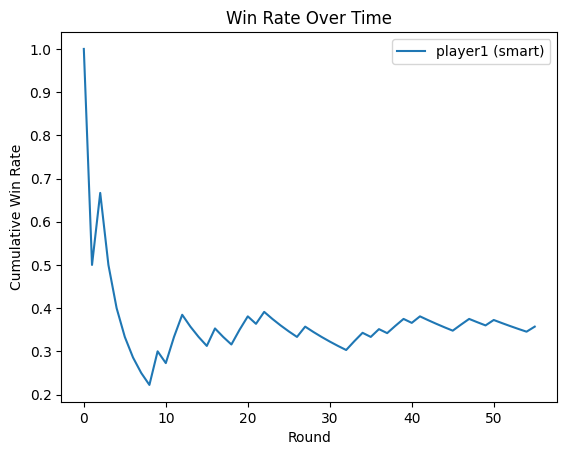

In [ ]:
for player in results["player_stats"]:
    plt.plot(player["winrate_history"], label=f"{player['name']} ({player['type']})")
    plt.xlabel("Round")
    plt.ylabel("Cumulative Win Rate")
    plt.title("Win Rate Over Time")
    plt.legend()
    plt.show()

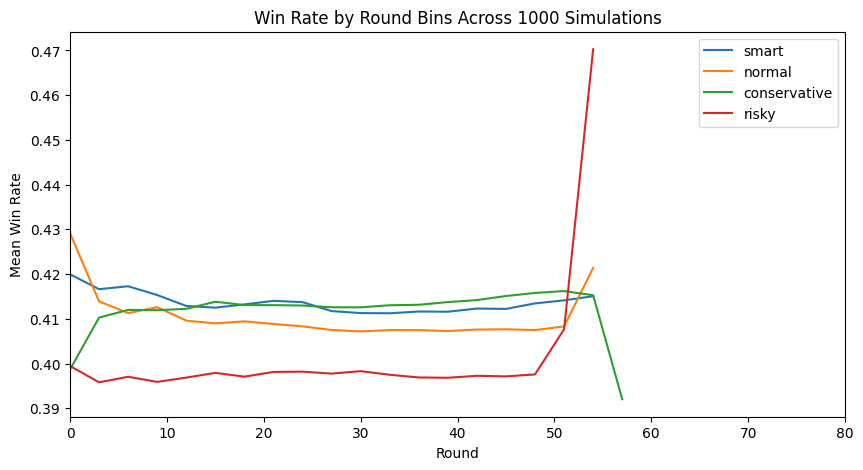

In [ ]:

def plot_winrate_by_bucket(all_results, bucket_size=5, label="smart"):
    max_rounds = max(r["rounds_played"] for r in all_results)
    buckets = range(0, max_rounds, bucket_size)
    mean_winrates = []

    for start in buckets:
        end = start + bucket_size
        rates = []
        for r in all_results:
            history = r["player_stats"][0]["winrate_history"]
            bucket_rates = history[start:end]
            if bucket_rates:
                rates.append(np.mean(bucket_rates))
        if rates:
            mean_winrates.append(np.mean(rates))

    plt.plot(list(buckets)[:len(mean_winrates)], mean_winrates, label=label)

plt.figure(figsize=(10, 5))
plot_winrate_by_bucket(smart_results, bucket_size=3, label="smart")
plot_winrate_by_bucket(normal_results, bucket_size=3, label="normal")
plot_winrate_by_bucket(conservative_results, bucket_size=3, label="conservative")
plot_winrate_by_bucket(risky_results, bucket_size=3, label="risky")
plt.xlabel("Round")
plt.ylabel("Mean Win Rate")
plt.title("Win Rate by Round Bins Across 1000 Simulations")
plt.xlim(0, 80)
plt.legend()
plt.show()